<a href="https://colab.research.google.com/github/Aslngsng/KMeans-Clustering/blob/main/Kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries

from sklearn.cluster import KMeans
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

UsageError: Line magic function `%motplotlib` not found.


In [ ]:
#get the image and its corresponding RGB Values

img = Image.open('tiger')
img_np=np.asarray(img)
img_np[0:2]

array([[[47, 49, 51],
        [45, 47, 49],
        [41, 44, 45],
        ...,
        [43, 36, 38],
        [43, 36, 38],
        [43, 36, 38]],

       [[47, 49, 51],
        [45, 47, 49],
        [41, 44, 45],
        ...,
        [48, 41, 43],
        [48, 41, 43],
        [48, 41, 43]]], dtype=uint8)

In [ ]:
#get tje image dimensions

img_np.shape

# for feeding this data into algorithm,
# you must change the shape of this data into a data set
# 800 x 800 = 640,000(rows), 3(columns)

(800, 800, 3)

In [ ]:
#reshape the data

pixels = img_np.reshape(img_np.shape[0]*img_np.shape[1], img_np.shape[2])
pixels.shape

(640000, 3)

In [ ]:
# define the k-means model

model = KMeans(n_clusters=16)
model.fit(pixels)

# after the model if trained, model.labers_ is used to obtained the number of cluster
# that is asisgned to each data point or each pixel
# model.cluster_centers_ gives us the coordinates or the RGB
# values of the 16 cluster centers

KMeans(n_clusters=16)

In [ ]:
# define the cluster centres

pixel_centroids = model.labels_
cluster_centers = model.cluster_centers_
pixel_centroids

array([11, 11, 11, ...,  2,  2, 13], dtype=int32)

In [ ]:
cluster_centers

array([[ 26.31324481,  28.63051505,  31.4631992 ],
       [158.59840803, 164.01553944, 165.27752991],
       [105.7559848 , 106.76559436, 107.13240384],
       [211.75302151, 212.78111058, 214.36385916],
       [206.04125688, 167.14875982, 118.5109173 ],
       [ 62.06957142,  61.65421094,  64.09213435],
       [174.3328843 , 125.54505314,  53.62655291],
       [130.43888935, 136.39302537, 137.8089965 ],
       [204.95012795, 124.20301393, 159.49707137],
       [220.36178641, 163.09774405, 193.16121096],
       [234.76045638, 239.12038354, 239.6615262 ],
       [ 43.37400705,  44.47054076,  46.86185803],
       [106.61764834,  75.14379964,  36.50787795],
       [ 83.87855203,  82.25197919,  84.45137109],
       [158.21590496, 111.9281125 , 108.70766153],
       [185.41570929, 190.41792477, 190.93586552]])

In [ ]:
# cluster assignment
final = np.zeros((pixel_centroids.shape[0], 3))
for cluster_no in range(16):
  final[pixel_centroids == cluster_no] = cluster_centers[cluster_no]
final[0:5]

array([[43.37400705, 44.47054076, 46.86185803],
       [43.37400705, 44.47054076, 46.86185803],
       [43.37400705, 44.47054076, 46.86185803],
       [43.37400705, 44.47054076, 46.86185803],
       [43.37400705, 44.47054076, 46.86185803]])

In [ ]:
# reshape to original dimension

comp_image = final.reshape(img_np.shape[0], img_np.shape[1],3)
comp_image.shape

(800, 800, 3)

In [ ]:
# convert the pixel values to image

comp_image = Image.fromarray(np.uint8(comp_image))
comp_image.save ('tiger_compressed.png')
img_1 = mpimg.imread('tiger')
img_2 = mpimg.imread('tiger_compressed.png')

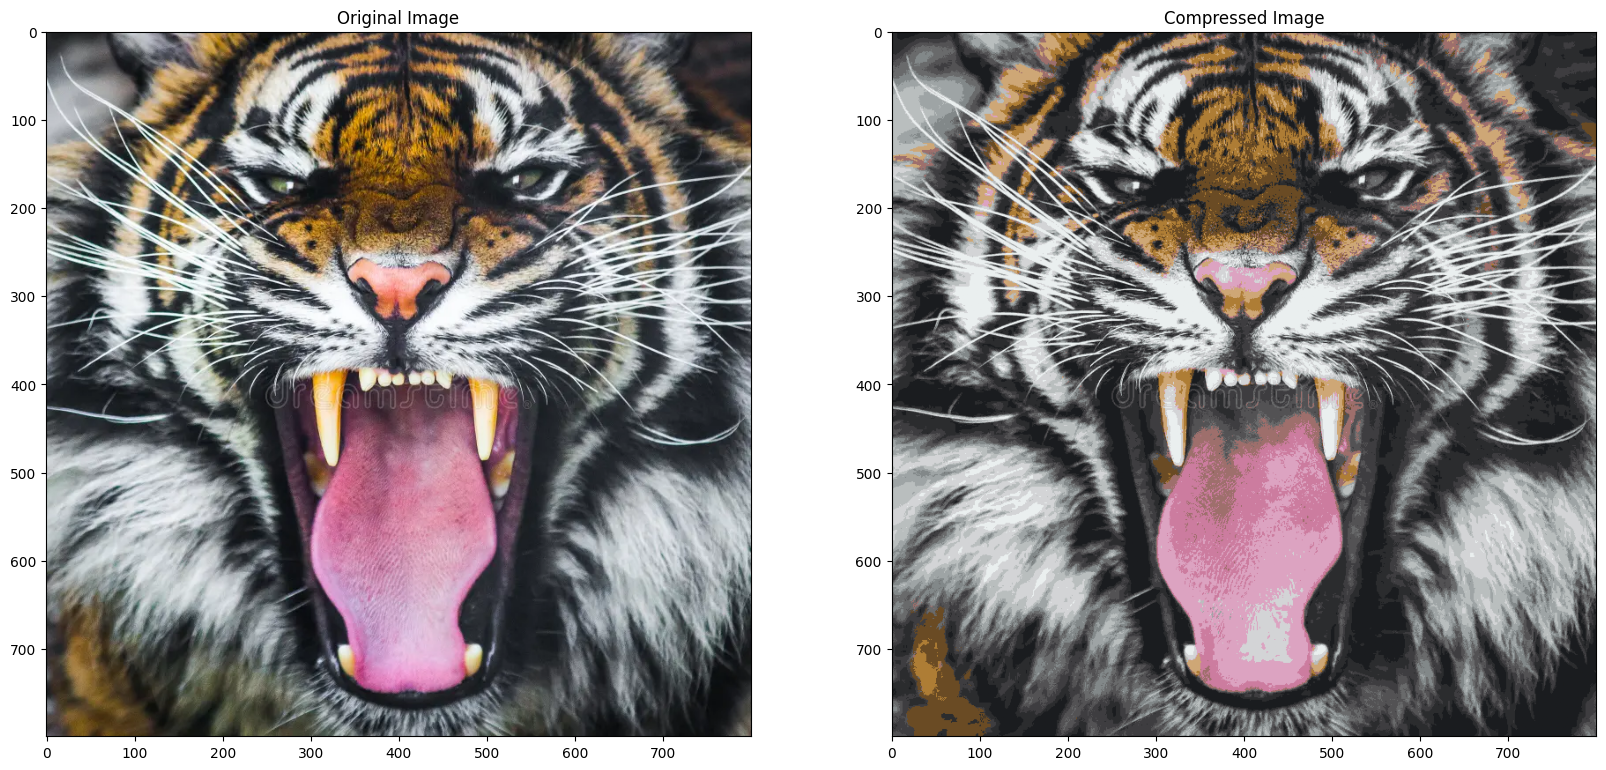

In [ ]:
#original plot vs compressed image

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,20))
ax1.imshow(img_1)
ax1.set_title ('Original Image')
ax2.imshow(img_2)
ax2.set_title('Compressed Image')
plt.show()
